ValueError: min() iterable argument is empty

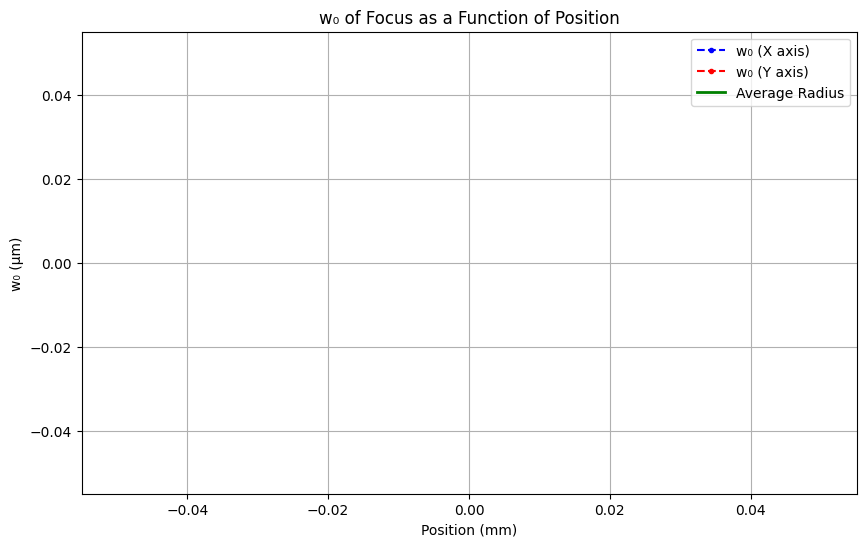

In [2]:
import os
import re
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter, label, center_of_mass
from scipy.optimize import curve_fit

# Constants
pixel_size_microns = 0.70  # pixel size in microns (corrected value)
pixel_size_cm = pixel_size_microns * 1e-4  # convert pixel size to cm
pulse_duration_fs = 65  # FWHM pulse duration in femtoseconds
pulse_duration_s = pulse_duration_fs * 1e-15  # convert to seconds
energy_J = 75e-3  # energy in joules for the focus

conversion_factor = 1e16  # to convert intensity to units of 10^16 W/cm^2

# Function to extract the position from the filename
def extract_position(filename):
    match = re.match(r"(\d+)(p\d+)?", filename)
    if match:
        # Extract integer part
        position = int(match.group(1))
        # If there is a decimal part (e.g., 'p5'), add it
        if match.group(2):
            position += float(match.group(2).replace('p', '.'))
        return position
    return None

# Function to perform connected component analysis and find the centroid of the largest component
def find_focus_with_connected_components(image, threshold_ratio=0.5):
    denoised_image = gaussian_filter(image, sigma=2)
    threshold = threshold_ratio * np.max(denoised_image)
    binary_image = denoised_image > threshold
    labeled_image, num_labels = label(binary_image)
    
    if num_labels == 0:
        return image.shape[0] // 2, image.shape[1] // 2
    
    region_sizes = np.bincount(labeled_image.ravel())
    largest_region_label = np.argmax(region_sizes[1:]) + 1
    focus_coords = center_of_mass(binary_image, labels=labeled_image, index=largest_region_label)
    return focus_coords

# Function to crop a square region around a given center
def crop_around_focus(image, focus_coords, crop_size):
    half_size = crop_size // 2
    y, x = map(int, focus_coords)
    start_x = max(x - half_size, 0)
    start_y = max(y - half_size, 0)
    end_x = min(x + half_size, image.shape[1])
    end_y = min(y + half_size, image.shape[0])
    return image[start_y:end_y, start_x:end_x]

# Corrected Gaussian function for fitting (matches laser beam profile)
def gauss_function(x, a, x0, w0, offset):
    return a * np.exp(-2 * (x - x0)**2 / w0**2) + offset

# Function to calculate the 1/e² radius (spot size)
def calculate_1e2_radius(projection):
    x = np.arange(len(projection))
    y = projection - np.min(projection)  # Subtract background
    y = y / np.max(y)  # Normalize
    
    # Initial guesses for the parameters
    mean = np.sum(x * y) / np.sum(y)
    sigma = np.sqrt(np.sum(y * (x - mean) ** 2) / np.sum(y))
    w0_initial = sigma * np.sqrt(2)  # Convert sigma to initial w0 estimate
    
    # Fit the data to the Gaussian function
    popt, _ = curve_fit(gauss_function, x, y, p0=[1, mean, w0_initial, 0])
    
    # w0 is directly the 1/e² radius
    w0 = abs(popt[2])
    
    return w0, popt  # Return w0 and fitted parameters

# Function to normalize projections to 1/3 of the image size
def normalize_projection(projection, img_size):
    return (projection / np.max(projection)) * (img_size / 3)

# Function to subtract background noise using a corner region
def subtract_background(image, corner_size=200):
    noise_region = image[:corner_size, :corner_size]
    noise_level = np.mean(noise_region)
    return image - noise_level, noise_level, corner_size

# Function to calculate intensity in units of 10^16 W/cm^2
def calculate_intensity(image, energy_joules):
    area_per_pixel = pixel_size_cm**2  # area per pixel in cm²
    total_counts = np.sum(image[image > 0])  # sum of positive counts
    intensity_per_count = energy_joules / (pulse_duration_s * area_per_pixel * total_counts) / conversion_factor
    intensity_map = image * intensity_per_count
    return intensity_map

# Folder path containing the images
folder_path = '/Volumes/Extreme SSD/kPAC/2025_08_21SeedCaustic'

# List and sort files by position
files = [f for f in os.listdir(folder_path) if f.endswith('.tif')]
files.sort(key=lambda f: extract_position(f))

crop_size = 600

# Lists to store positions and 1/e² radii
positions = []
radii_x = []
radii_y = []

# Loop over each file and analyze the focus
for file in files:
    position = extract_position(file)
    if position is None:
        continue  # Skip files that don't match the pattern
    positions.append(position)
    image_path = os.path.join(folder_path, file)
    image = imageio.imread(image_path)
    
    # Subtract background noise
    image, noise_level, corner_size = subtract_background(image)
    
    # Find the focus in the image
    focus = find_focus_with_connected_components(image)
    
    # Crop around the focus
    cropped = crop_around_focus(image, focus, crop_size)
    
    # Projections
    vertical_projection = np.sum(cropped, axis=0)
    horizontal_projection = np.sum(cropped, axis=1)
    
    # Calculate 1/e² radii along x and y
    radius_x, popt_x = calculate_1e2_radius(vertical_projection)
    radius_y, popt_y = calculate_1e2_radius(horizontal_projection)
    
    # Store radii
    radii_x.append(radius_x)
    radii_y.append(radius_y)
    
    # Convert cropped image to intensity map (in units of 10^16 W/cm²)
    intensity_map = calculate_intensity(cropped, energy_J)
    
    # Plot the results for each file
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    
    # Plot the original image with noise region and focus location
    axs[0].imshow(image, cmap='viridis', extent=[0, image.shape[1] * pixel_size_microns, image.shape[0] * pixel_size_microns, 0])
    axs[0].plot(focus[1] * pixel_size_microns, focus[0] * pixel_size_microns, 'ro', markersize=8)
    
    # Draw a square around the corner noise region
    axs[0].add_patch(plt.Rectangle((0, 0), corner_size * pixel_size_microns, corner_size * pixel_size_microns, edgecolor='blue', facecolor='none', linewidth=2))
    axs[0].set_title(f'Original Image (Position: {position})\nNoise Level: {noise_level:.2f}')
    axs[0].set_xlabel('X (microns)')
    axs[0].set_ylabel('Y (microns)')
    
    # Plot the focus intensity map with projections and fits
    axs[1].imshow(intensity_map, cmap='viridis', extent=[0, cropped.shape[1] * pixel_size_microns, cropped.shape[0] * pixel_size_microns, 0], origin='lower')
    axs[1].set_title('Focus Intensity Map ({:.0f} mJ)'.format(1000 * energy_J))
    axs[1].set_xlabel('X (microns)')
    axs[1].set_ylabel('Y (microns)')
    cbar = plt.colorbar(axs[1].images[0], ax=axs[1], label='Intensity ($10^{16}$ W/cm$^2$)')
    
    # Overlay vertical and horizontal projections and fits
    x = np.arange(len(vertical_projection)) * pixel_size_microns
    y = np.arange(len(horizontal_projection)) * pixel_size_microns
    normalized_vertical = normalize_projection(vertical_projection, cropped.shape[0] * pixel_size_microns)
    normalized_horizontal = normalize_projection(horizontal_projection, cropped.shape[1] * pixel_size_microns)
    axs[1].plot(x, normalized_vertical, label='Vertical Projection', color='red')
    axs[1].plot(x, normalize_projection(gauss_function(np.arange(len(vertical_projection)), *popt_x), cropped.shape[0] * pixel_size_microns), label='Gaussian Fit', color='orange')
    axs[1].plot(normalized_horizontal, y, label='Horizontal Projection', color='blue')
    axs[1].plot(normalize_projection(gauss_function(np.arange(len(horizontal_projection)), *popt_y), cropped.shape[1] * pixel_size_microns), y, label='Gaussian Fit', color='green')
    axs[1].text(0.05, 0.95, f'w₀ₓ = {radius_x * pixel_size_microns:.2f} μm\nw₀ᵧ = {radius_y * pixel_size_microns:.2f} μm', transform=axs[1].transAxes, fontsize=12, color='white', verticalalignment='top', bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
    axs[1].legend()
    
    plt.tight_layout()
    plt.show()

# Convert radii from pixels to microns
radii_x_microns = np.array(radii_x) * pixel_size_microns
radii_y_microns = np.array(radii_y) * pixel_size_microns

# Calculate the average 1/e² radius
average_radius = (radii_x_microns + radii_y_microns) / 2

# Final plot: 1/e² radii as a function of position, in microns
plt.figure(figsize=(10, 6))
plt.plot(positions, radii_x_microns, 'b.--', label='w₀ (X axis)')
plt.plot(positions, radii_y_microns, 'r.--', label='w₀ (Y axis)')
plt.plot(positions, average_radius, 'g-', label='Average Radius', linewidth=2)

plt.xlabel('Position (mm)')
plt.ylabel('w₀ (μm)')
plt.title('w₀ of Focus as a Function of Position')
plt.legend()
plt.grid(True)

plt.xlim(min(positions), max(positions))
plt.ylim(0, max(max(radii_x_microns), max(radii_y_microns)) * 1.1)

plt.show()

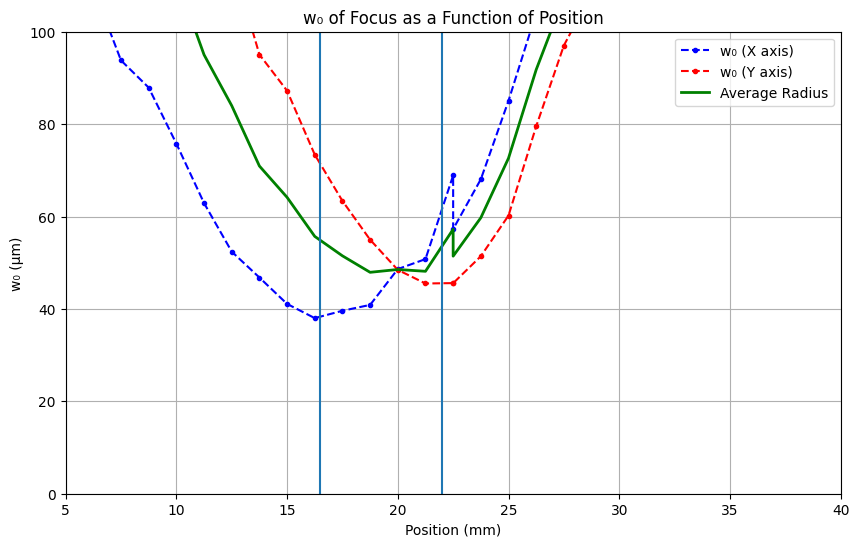

In [28]:
plt.figure(figsize=(10, 6))
mm_per_step = 50/20000
pos_mm = np.array(positions)*mm_per_step
plt.plot(pos_mm, radii_x_microns, 'b.--', label='w₀ (X axis)')
plt.plot(pos_mm, radii_y_microns, 'r.--', label='w₀ (Y axis)')
plt.plot(pos_mm, average_radius, 'g-', label='Average Radius', linewidth=2)

plt.xlabel('Position (mm)')
plt.ylabel('w₀ (μm)')
plt.title('w₀ of Focus as a Function of Position')
plt.legend()
plt.grid(True)

plt.xlim(min(pos_mm), max(pos_mm))
#plt.xlim(0,15000)
plt.ylim(0, max(max(radii_x_microns), max(radii_y_microns)) * 1.1)
plt.ylim(0,100)
plt.axvline(16.5)
plt.axvline(22)

# bitmap version:

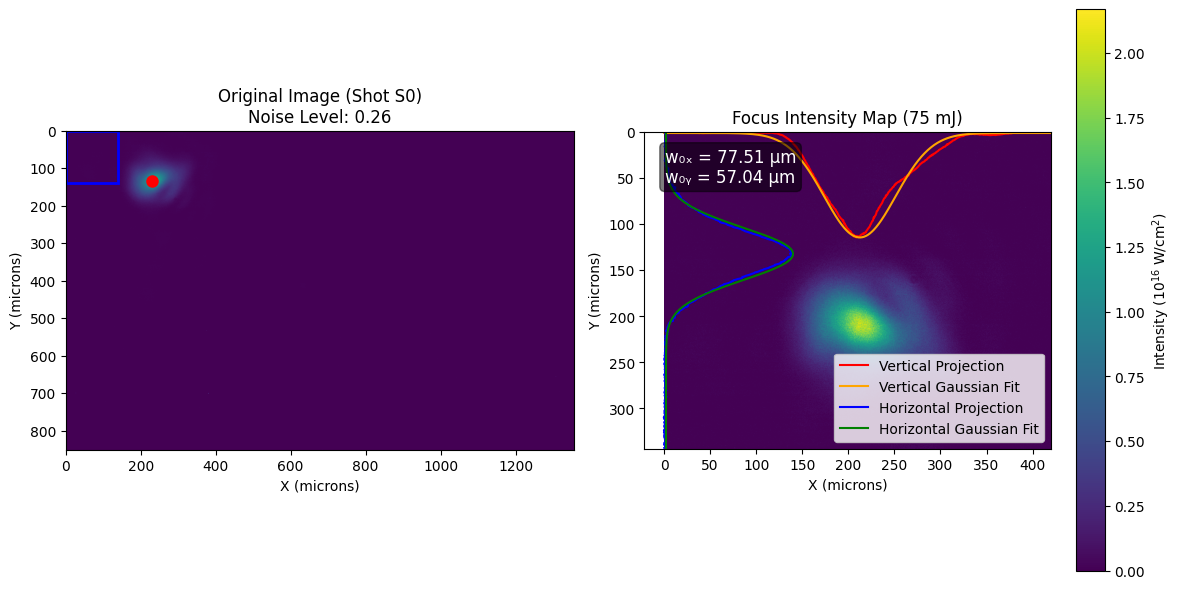

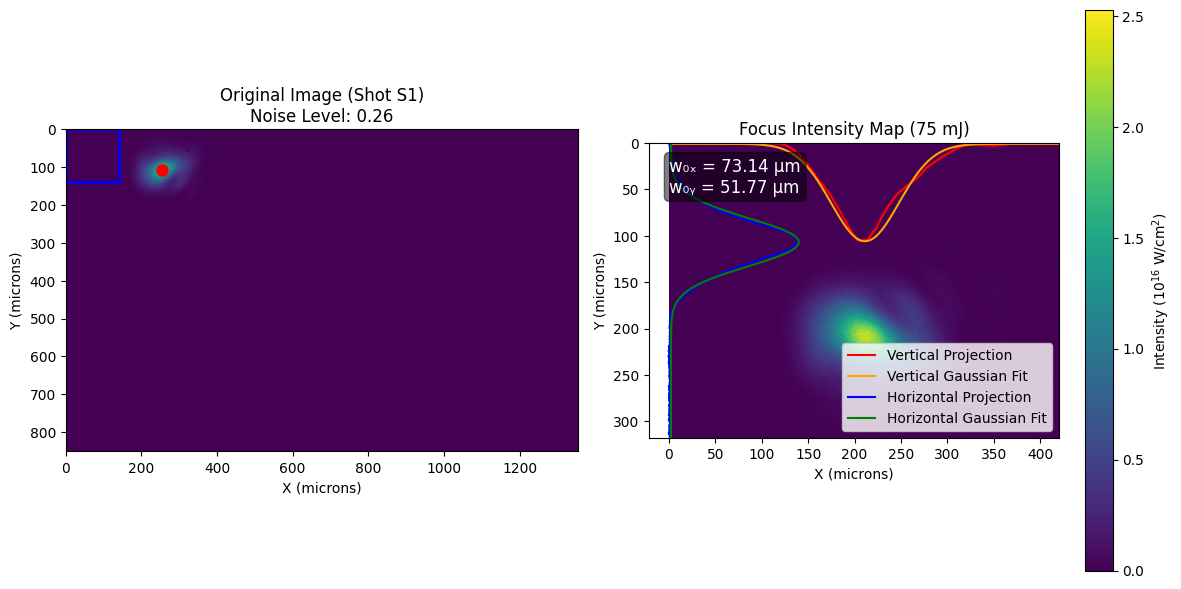

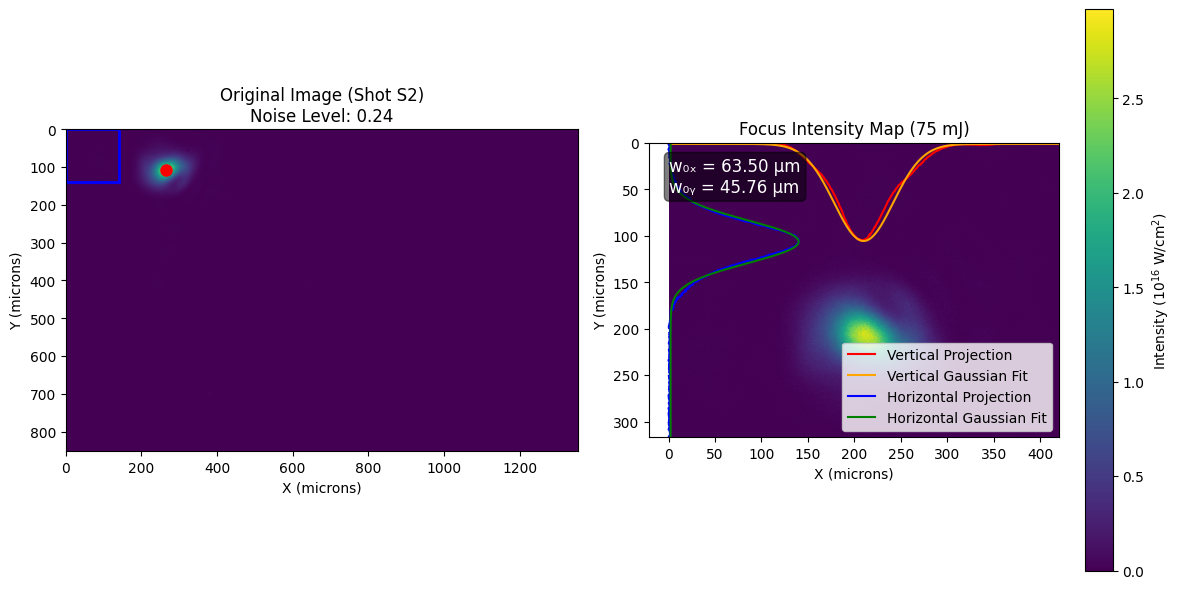

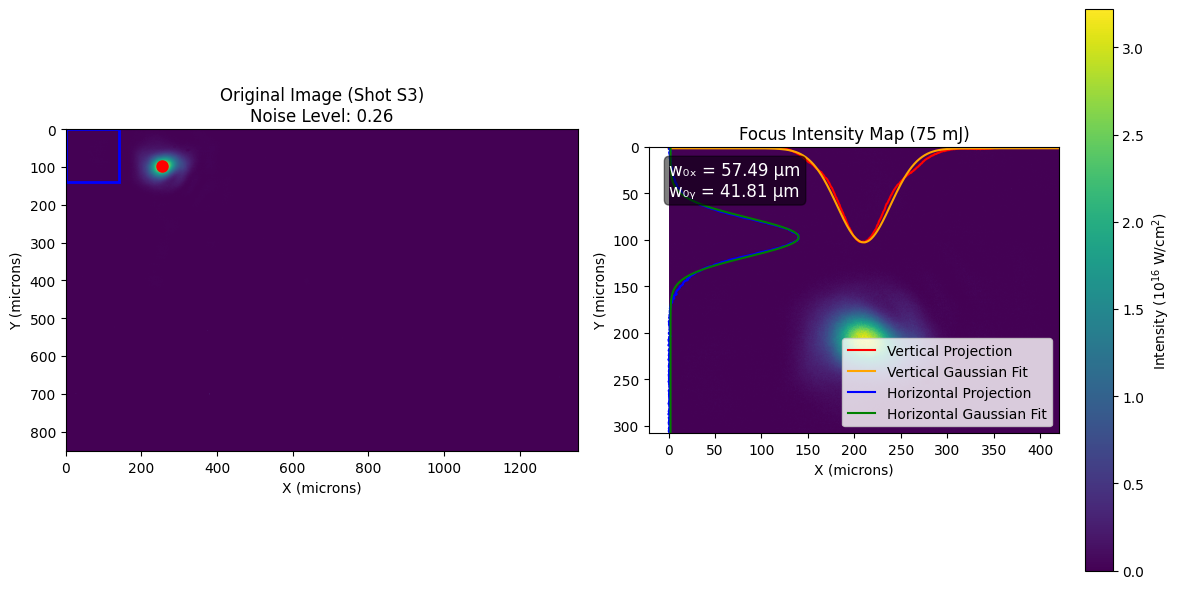

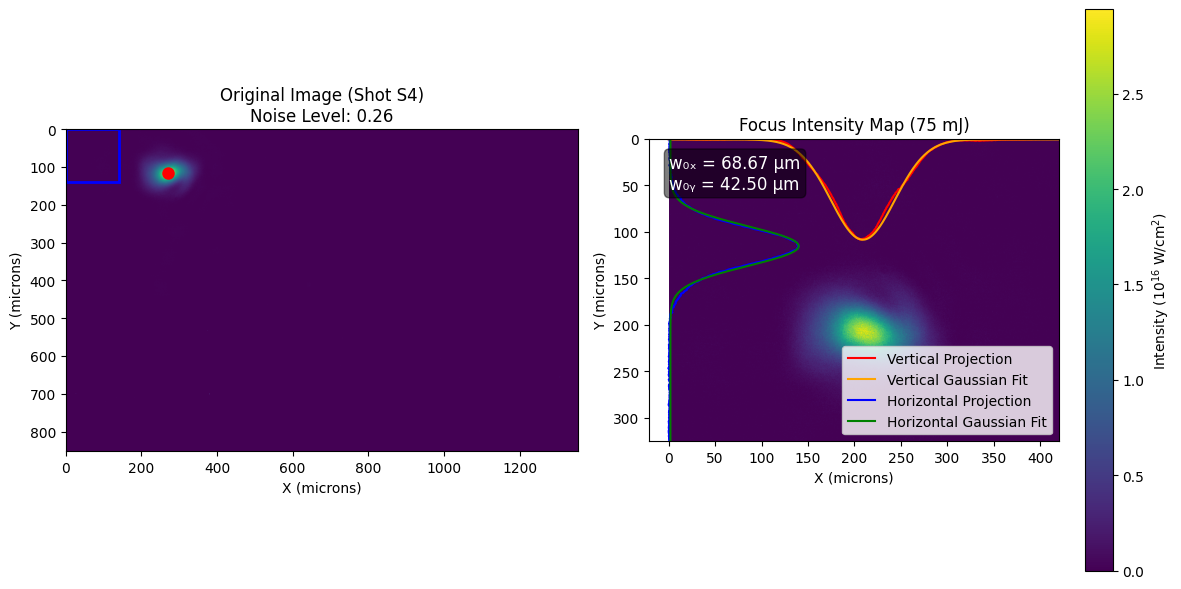

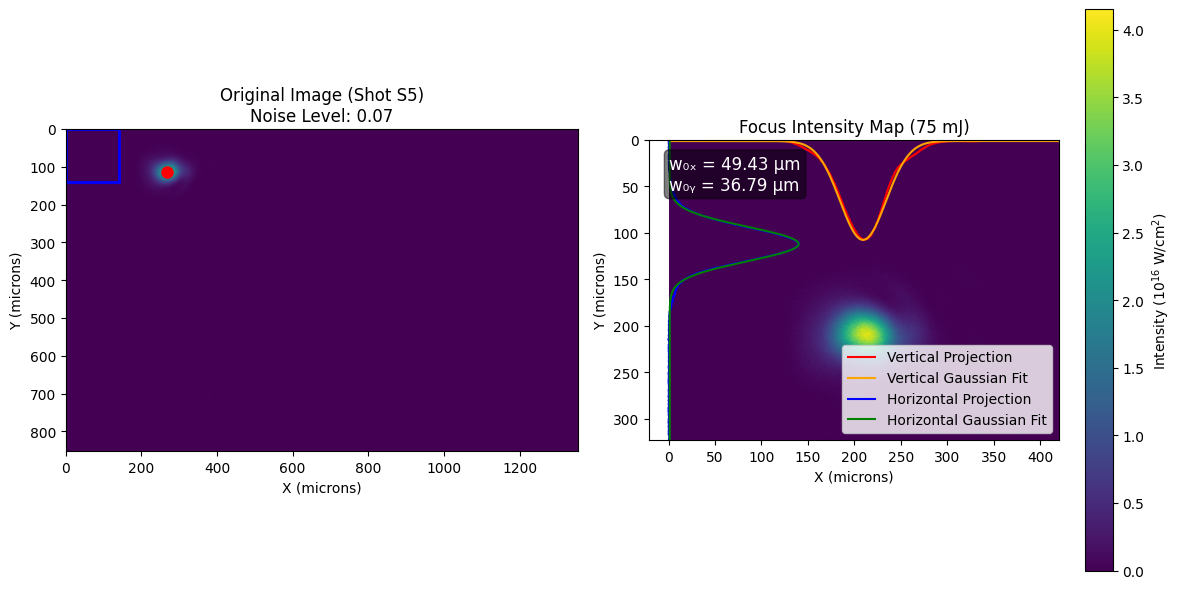

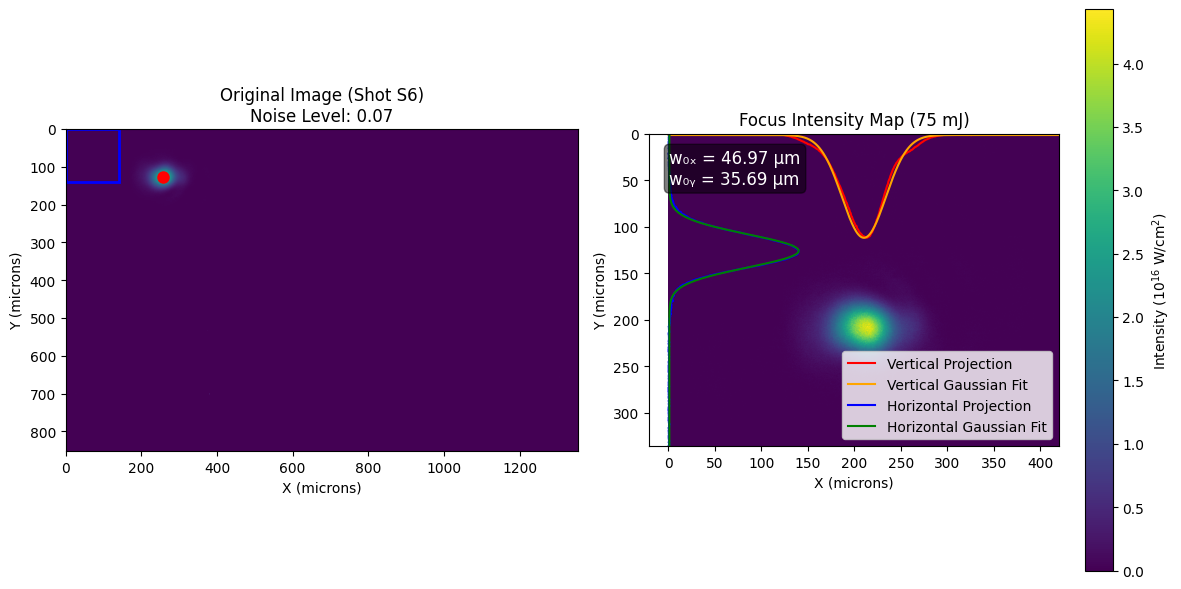

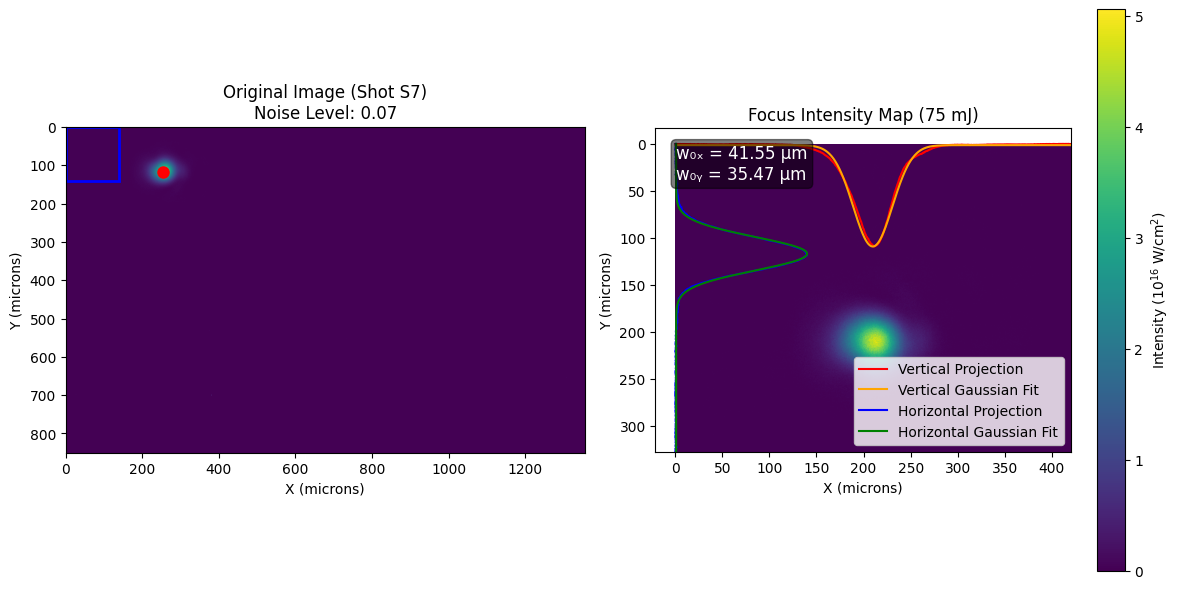

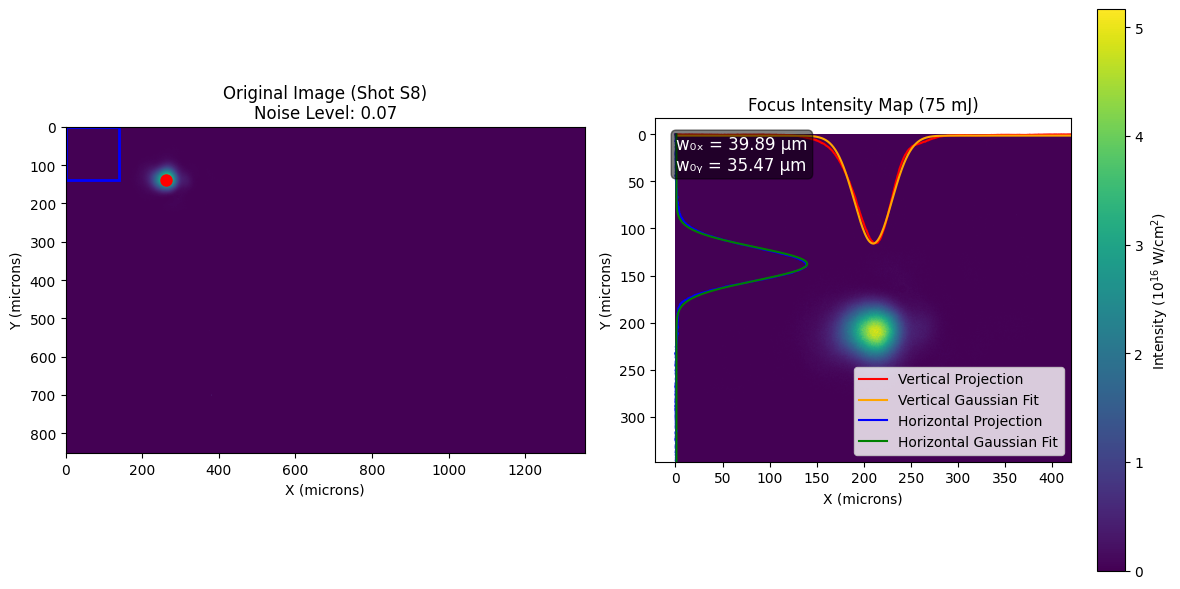

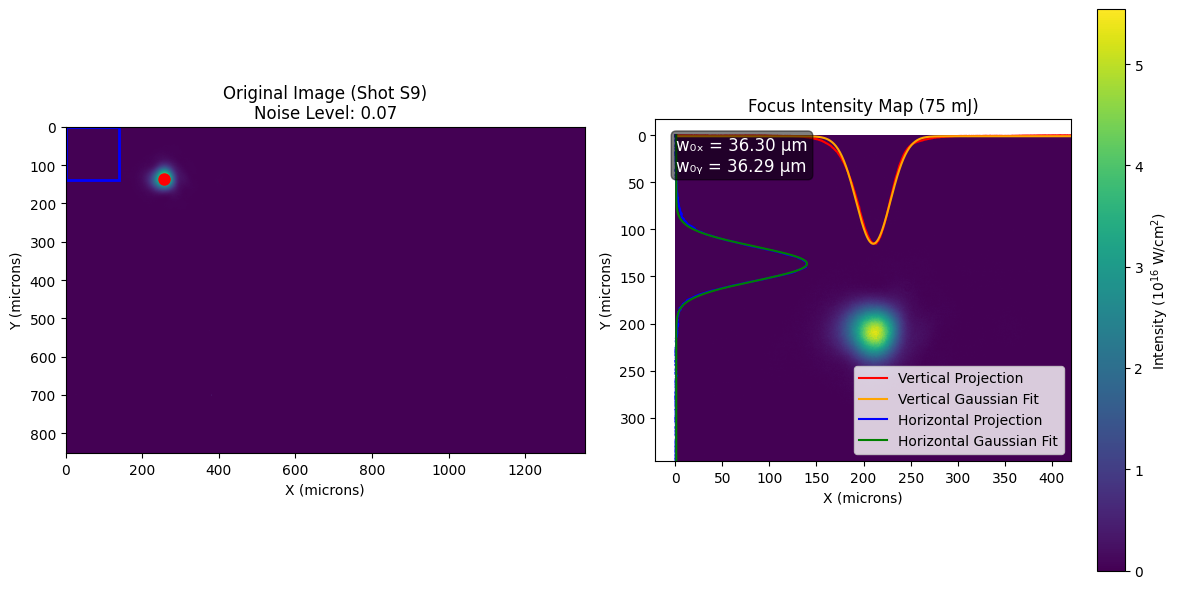

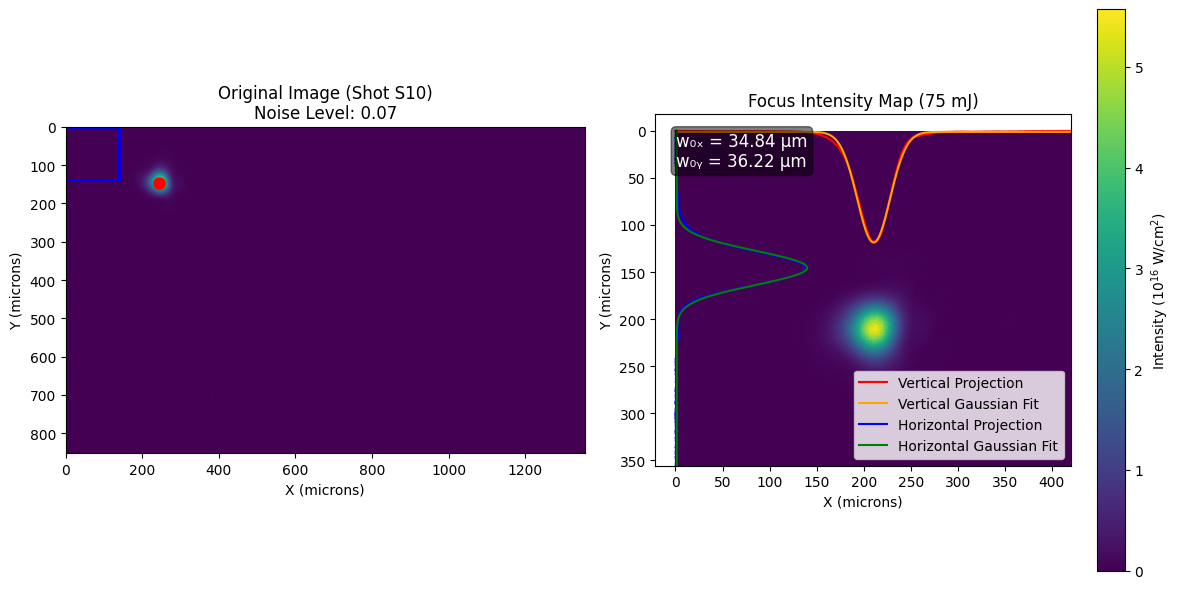

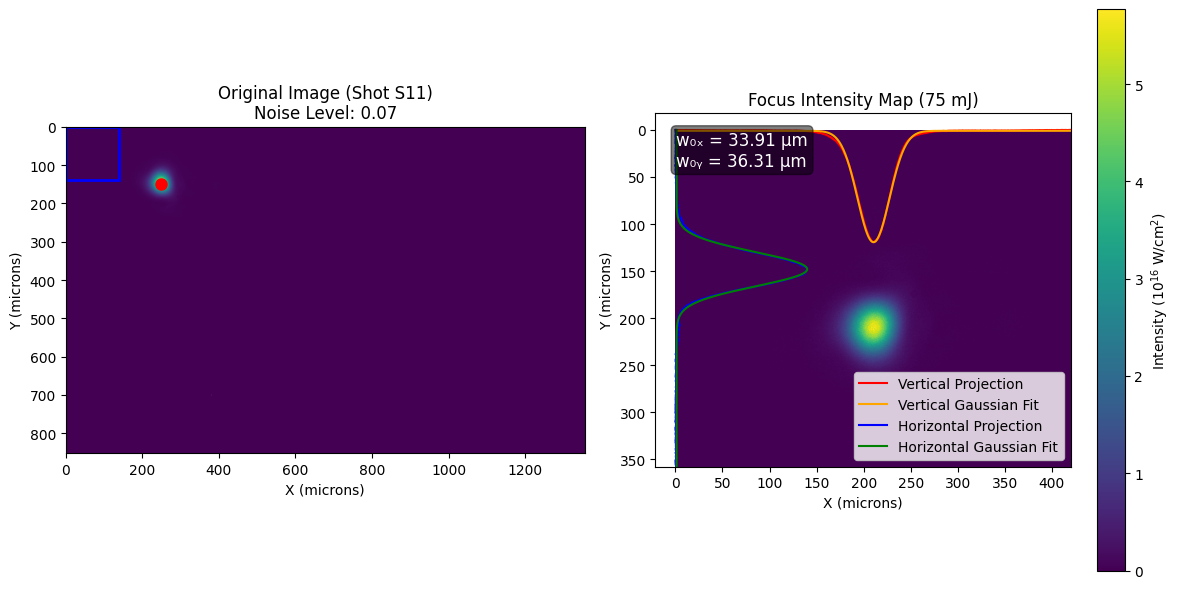

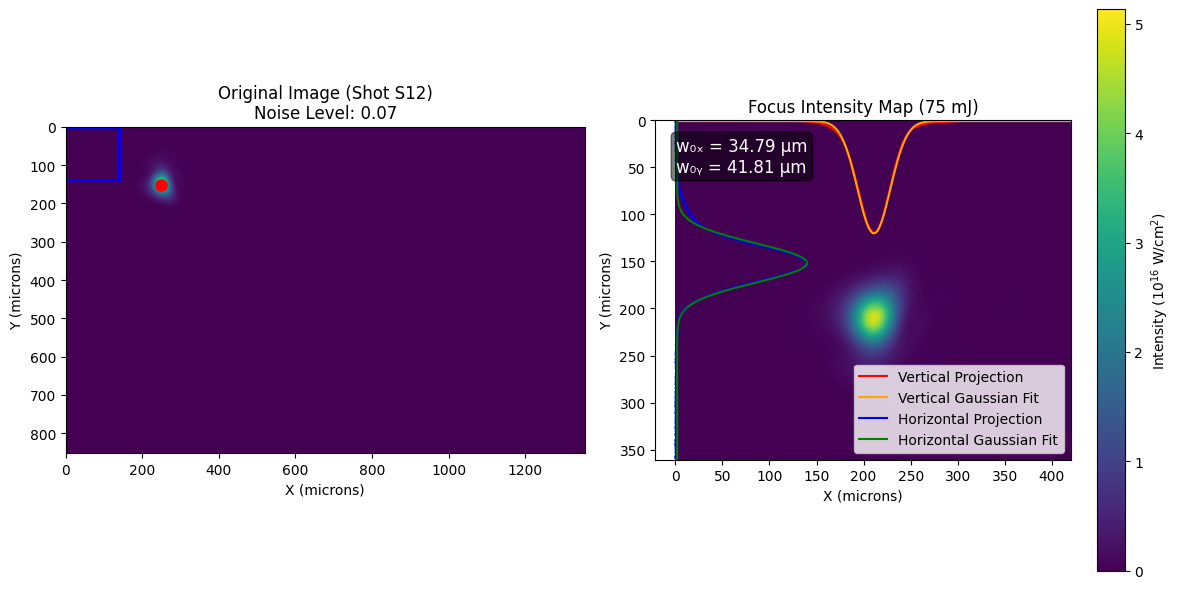

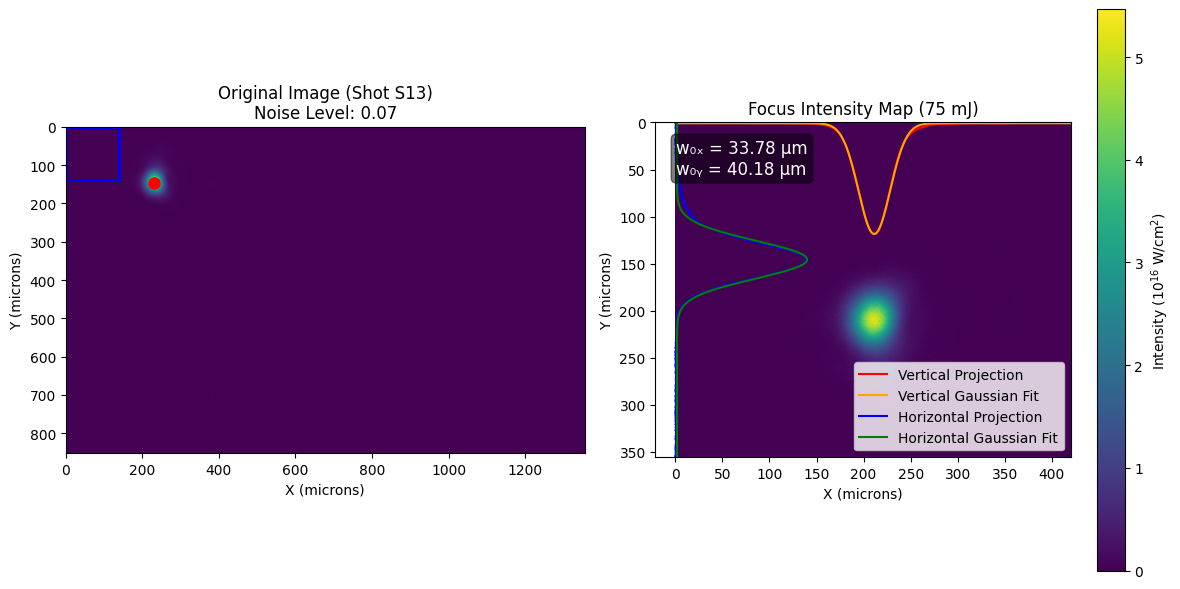

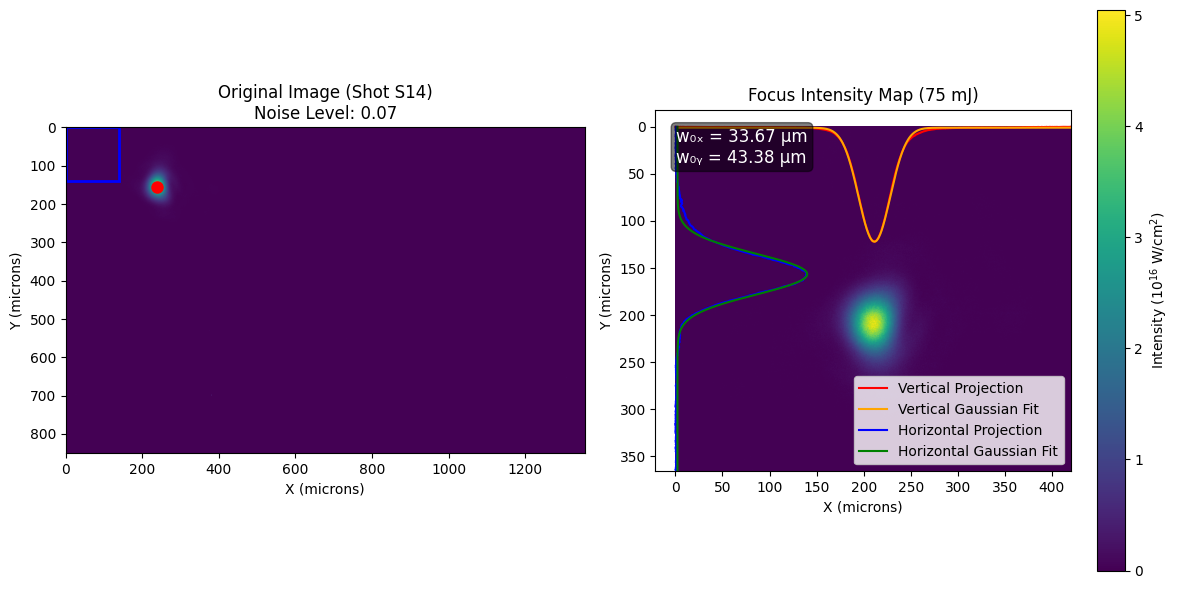

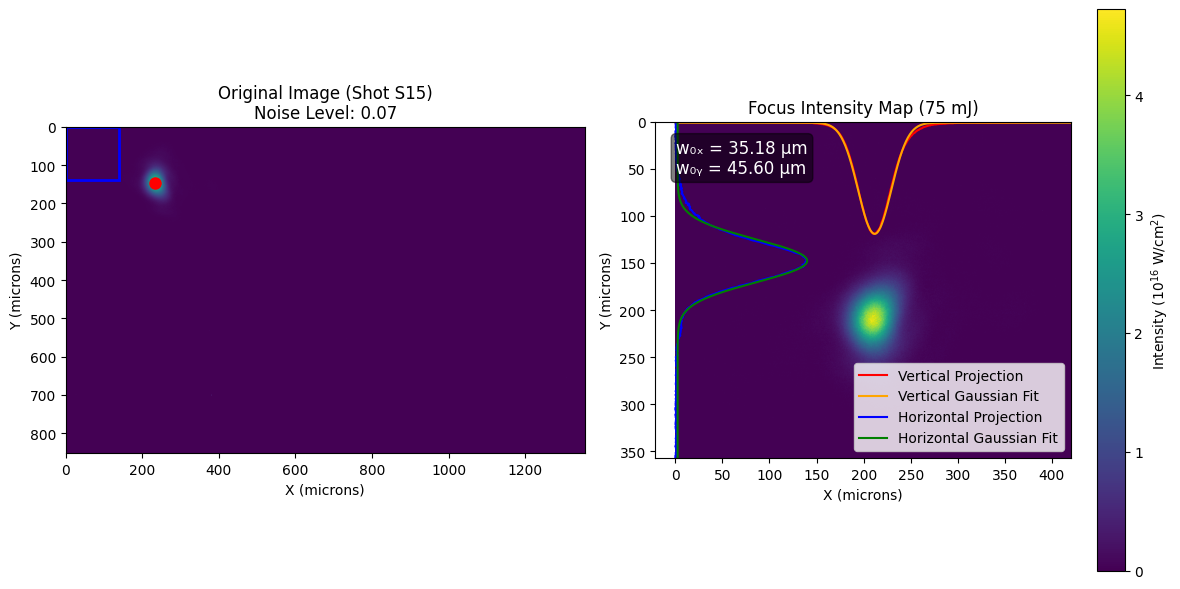

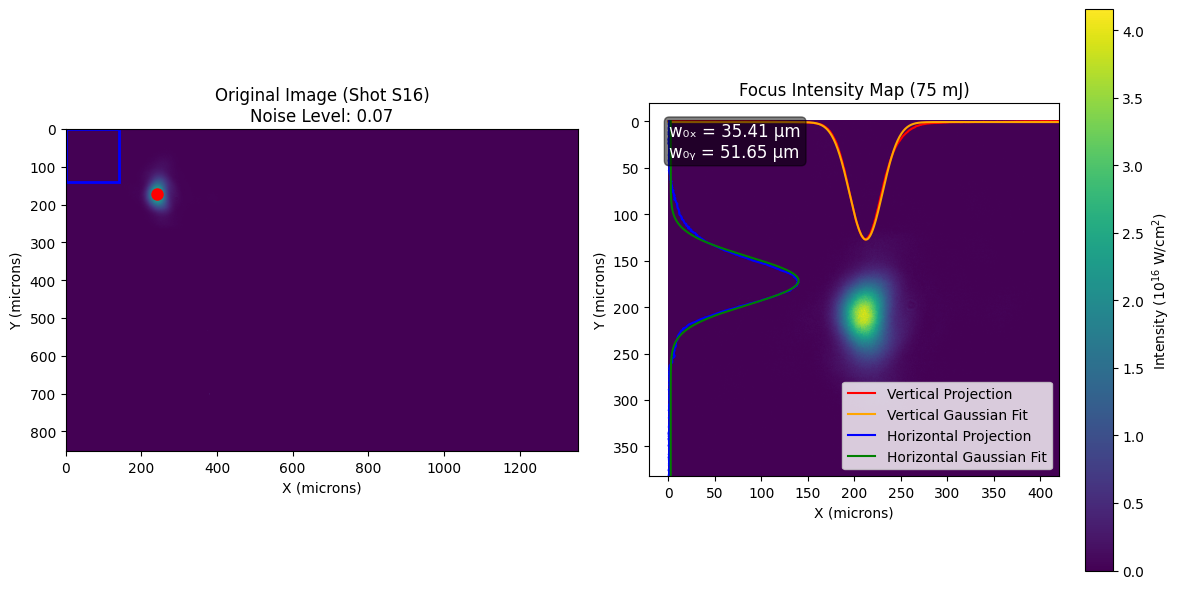

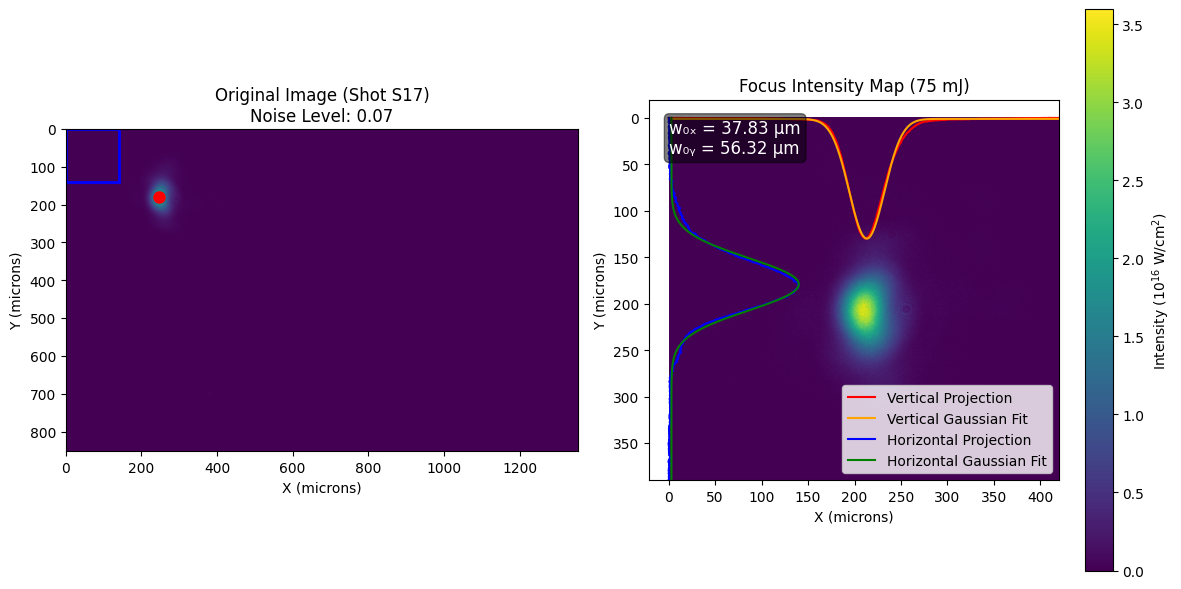

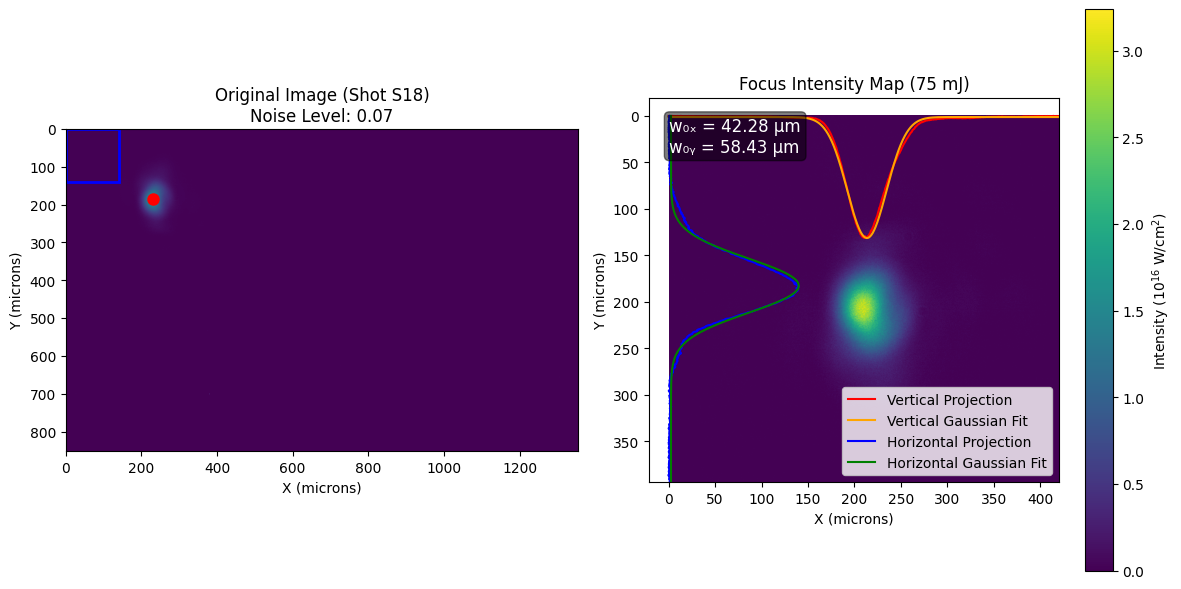

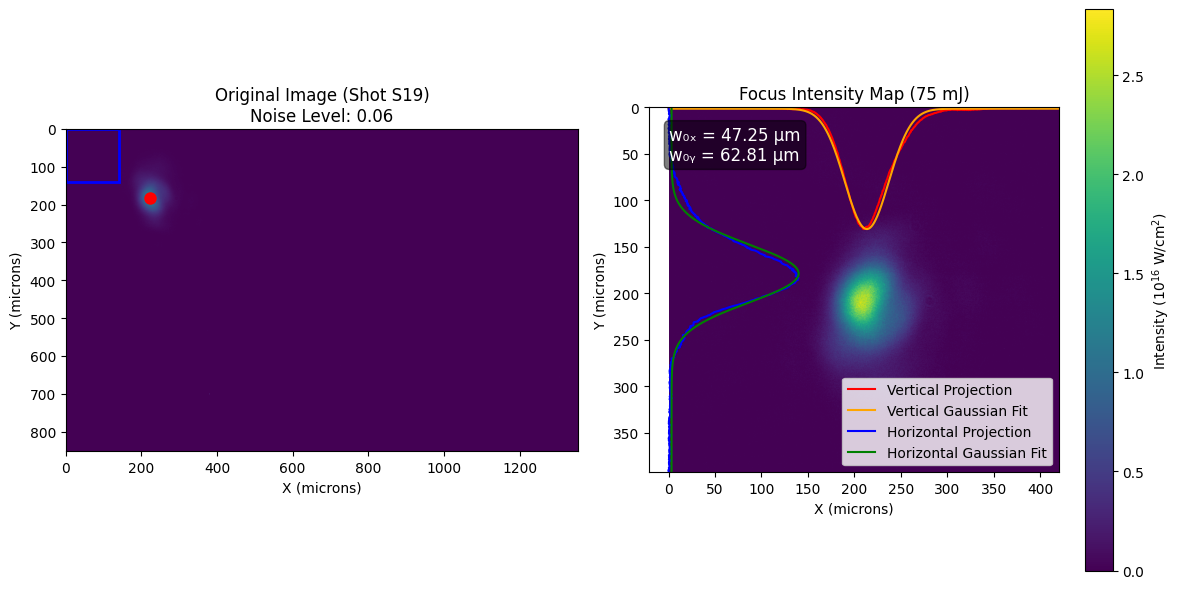

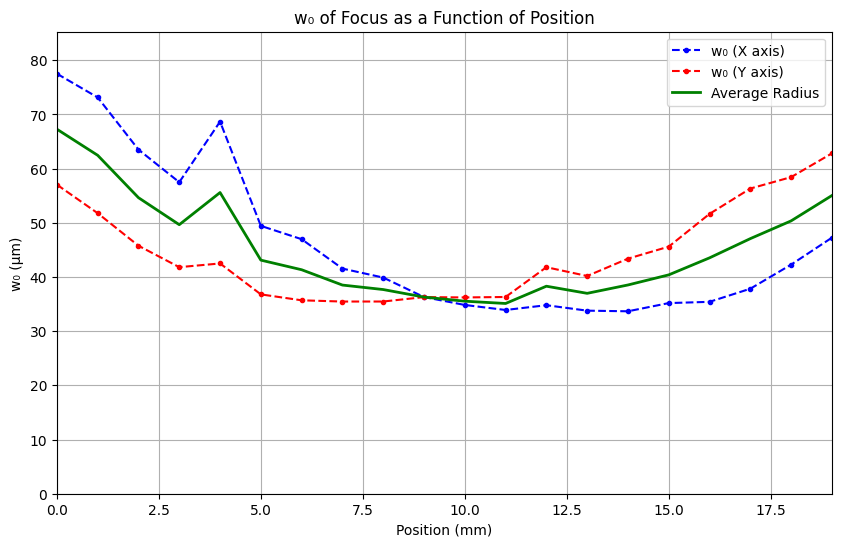

In [3]:
import os
import re
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter, label, center_of_mass
from scipy.optimize import curve_fit

# =========================
# User-set parameters
# =========================
folder_path = '/Volumes/Extreme SSD/kPAC/2025_08_21SeedCaustic/try2'  # folder with S*.bm / S*.bmp files
shot_step_mm = 1.0  # <-- distance between consecutive shots in mm (adjust to your actual spacing)

# Constants (unchanged)
pixel_size_microns = 0.70  # pixel size in microns (corrected value)
pixel_size_cm = pixel_size_microns * 1e-4  # convert pixel size to cm
pulse_duration_fs = 65  # FWHM pulse duration in femtoseconds
pulse_duration_s = pulse_duration_fs * 1e-15  # convert to seconds
energy_J = 75e-3  # energy in joules for the focus

conversion_factor = 1e16  # to convert intensity to units of 10^16 W/cm^2

# -------- Helpers for new filename format --------
# Expect filenames like 'S10.bm' or 'S10.bmp' (case-insensitive).
def extract_shot_number(filename: str):
    m = re.match(r"(?i)^s(\d+)\.(?:bm|bmp)$", filename)
    return int(m.group(1)) if m else None

# Function to perform connected component analysis and find the centroid of the largest component
def find_focus_with_connected_components(image, threshold_ratio=0.5):
    denoised_image = gaussian_filter(image, sigma=2)
    threshold = threshold_ratio * np.max(denoised_image)
    binary_image = denoised_image > threshold
    labeled_image, num_labels = label(binary_image)

    if num_labels == 0:
        return image.shape[0] // 2, image.shape[1] // 2

    region_sizes = np.bincount(labeled_image.ravel())
    largest_region_label = np.argmax(region_sizes[1:]) + 1
    focus_coords = center_of_mass(binary_image, labels=labeled_image, index=largest_region_label)
    return focus_coords

# Function to crop a square region around a given center
def crop_around_focus(image, focus_coords, crop_size):
    half_size = crop_size // 2
    y, x = map(int, focus_coords)
    start_x = max(x - half_size, 0)
    start_y = max(y - half_size, 0)
    end_x = min(x + half_size, image.shape[1])
    end_y = min(y + half_size, image.shape[0])
    return image[start_y:end_y, start_x:end_x]

# Corrected Gaussian function for fitting (matches laser beam profile)
def gauss_function(x, a, x0, w0, offset):
    return a * np.exp(-2 * (x - x0)**2 / w0**2) + offset

# Function to calculate the 1/e² radius (spot size)
def calculate_1e2_radius(projection):
    x = np.arange(len(projection))
    y = projection - np.min(projection)  # Subtract background
    ymax = np.max(y)
    if ymax <= 0:
        # Fall back to zeros to avoid divide-by-zero; return NaNs so plot shows gaps
        return np.nan, (np.nan, np.nan, np.nan, np.nan)
    y = y / ymax

    # Initial guesses for the parameters
    mean = np.sum(x * y) / np.sum(y)
    sigma = np.sqrt(np.sum(y * (x - mean) ** 2) / np.sum(y))
    w0_initial = sigma * np.sqrt(2)  # Convert sigma to initial w0 estimate

    # Fit the data to the Gaussian function
    try:
        popt, _ = curve_fit(gauss_function, x, y, p0=[1, mean, w0_initial, 0], maxfev=10000)
        w0 = abs(popt[2])  # 1/e^2 radius
    except Exception:
        w0, popt = np.nan, (np.nan, np.nan, np.nan, np.nan)

    return w0, popt  # Return w0 and fitted parameters

# Function to normalize projections to 1/3 of the image size
def normalize_projection(projection, img_size):
    m = np.max(projection)
    return (projection / m) * (img_size / 3) if m > 0 else projection * 0.0

# Function to subtract background noise using a corner region
def subtract_background(image, corner_size=200):
    noise_region = image[-corner_size:, -corner_size:]
    noise_level = np.mean(noise_region)
    return image - noise_level, noise_level, corner_size

# Function to calculate intensity in units of 10^16 W/cm^2
def calculate_intensity(image, energy_joules):
    area_per_pixel = pixel_size_cm**2  # area per pixel in cm²
    positive = image > 0
    total_counts = np.sum(image[positive]) if np.any(positive) else np.nan
    if not np.isfinite(total_counts) or total_counts == 0:
        return np.zeros_like(image, dtype=float)
    intensity_per_count = energy_joules / (pulse_duration_s * area_per_pixel * total_counts) / conversion_factor
    intensity_map = image * intensity_per_count
    return intensity_map

# -------- Load image list (bitmaps) --------
# Accept .bm and .bmp, case-insensitive
all_files = os.listdir(folder_path)
files = [f for f in all_files if re.search(r"(?i)\.(bm|bmp)$", f)]
# Sort by shot number; skip names that don't match S<number>.<ext>
files = [f for f in files if extract_shot_number(f) is not None]
files.sort(key=lambda f: extract_shot_number(f))

crop_size = 600

# Lists to store positions and 1/e² radii
positions = []
radii_x = []
radii_y = []

# Loop over each file and analyze the focus
for file in files:
    shot_no = extract_shot_number(file)
    if shot_no is None:
        continue

    # Equidistant positions: position [mm] = shot_no * step
    position_mm = shot_no * shot_step_mm
    positions.append(position_mm)

    image_path = os.path.join(folder_path, file)
    image = imageio.imread(image_path)

    # Ensure grayscale 2D
    if image.ndim == 3:
        # Convert RGB(A) to luminance by averaging; tweak if you prefer a weighted conversion
        image = image.mean(axis=2)

    # Subtract background noise
    image, noise_level, corner_size = subtract_background(image)

    # Find the focus in the image
    focus = find_focus_with_connected_components(image)

    # Crop around the focus
    cropped = crop_around_focus(image, focus, crop_size)

    # Projections
    vertical_projection = np.sum(cropped, axis=0)
    horizontal_projection = np.sum(cropped, axis=1)

    # Calculate 1/e² radii along x and y
    radius_x, popt_x = calculate_1e2_radius(vertical_projection)
    radius_y, popt_y = calculate_1e2_radius(horizontal_projection)

    # Store radii (in pixels for now)
    radii_x.append(radius_x)
    radii_y.append(radius_y)

    # Convert cropped image to intensity map (in units of 10^16 W/cm²)
    intensity_map = calculate_intensity(cropped, energy_J)

    # Plot the results for each file
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    # Plot the original image with noise region and focus location
    axs[0].imshow(
        image,
        cmap='viridis',
        extent=[0, image.shape[1] * pixel_size_microns,
                image.shape[0] * pixel_size_microns, 0]
    )
    axs[0].plot(focus[1] * pixel_size_microns, focus[0] * pixel_size_microns, 'ro', markersize=8)

    # Draw a square around the corner noise region
    axs[0].add_patch(plt.Rectangle(
        (0, 0),
        corner_size * pixel_size_microns,
        corner_size * pixel_size_microns,
        edgecolor='blue', facecolor='none', linewidth=2
    ))
    axs[0].set_title(f'Original Image (Shot S{shot_no})\nNoise Level: {noise_level:.2f}')
    axs[0].set_xlabel('X (microns)')
    axs[0].set_ylabel('Y (microns)')

    # Plot the focus intensity map with projections and fits
    axs[1].imshow(
        intensity_map,
        cmap='viridis',
        extent=[0, cropped.shape[1] * pixel_size_microns,
                cropped.shape[0] * pixel_size_microns, 0],
        origin='lower'
    )
    axs[1].set_title('Focus Intensity Map ({:.0f} mJ)'.format(1000 * energy_J))
    axs[1].set_xlabel('X (microns)')
    axs[1].set_ylabel('Y (microns)')
    cbar = plt.colorbar(axs[1].images[0], ax=axs[1], label='Intensity ($10^{16}$ W/cm$^2$)')

    # Overlay vertical and horizontal projections and fits
    x_um = np.arange(len(vertical_projection)) * pixel_size_microns
    y_um = np.arange(len(horizontal_projection)) * pixel_size_microns
    normalized_vertical = normalize_projection(vertical_projection, cropped.shape[0] * pixel_size_microns)
    normalized_horizontal = normalize_projection(horizontal_projection, cropped.shape[1] * pixel_size_microns)

    axs[1].plot(x_um, normalized_vertical, label='Vertical Projection', color='red')
    if np.all(np.isfinite(popt_x)):
        axs[1].plot(
            x_um,
            normalize_projection(gauss_function(np.arange(len(vertical_projection)), *popt_x),
                                 cropped.shape[0] * pixel_size_microns),
            label='Vertical Gaussian Fit', color='orange'
        )

    axs[1].plot(normalized_horizontal, y_um, label='Horizontal Projection', color='blue')
    if np.all(np.isfinite(popt_y)):
        axs[1].plot(
            normalize_projection(gauss_function(np.arange(len(horizontal_projection)), *popt_y),
                                 cropped.shape[1] * pixel_size_microns),
            y_um, label='Horizontal Gaussian Fit', color='green'
        )

    axs[1].text(
        0.05, 0.95,
        f'w₀ₓ = {radius_x * pixel_size_microns:.2f} μm\nw₀ᵧ = {radius_y * pixel_size_microns:.2f} μm',
        transform=axs[1].transAxes, fontsize=12, color='white',
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='black', alpha=0.5)
    )
    axs[1].legend()

    plt.tight_layout()
    plt.show()

# Convert radii from pixels to microns
radii_x_microns = np.array(radii_x) * pixel_size_microns
radii_y_microns = np.array(radii_y) * pixel_size_microns

# Calculate the average 1/e² radius
average_radius = (radii_x_microns + radii_y_microns) / 2

# Final plot: 1/e² radii as a function of position, in microns
plt.figure(figsize=(10, 6))
plt.plot(positions, radii_x_microns, 'b.--', label='w₀ (X axis)')
plt.plot(positions, radii_y_microns, 'r.--', label='w₀ (Y axis)')
plt.plot(positions, average_radius, 'g-', label='Average Radius', linewidth=2)

plt.xlabel('Position (mm)')
plt.ylabel('w₀ (μm)')
plt.title('w₀ of Focus as a Function of Position')
plt.legend()
plt.grid(True)

plt.xlim(min(positions), max(positions))
plt.ylim(0, np.nanmax([np.nanmax(radii_x_microns), np.nanmax(radii_y_microns)]) * 1.1)

plt.show()
